"""Customer Churn Prediction
Author: Nishant Kumar
Tools: Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn
"""

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Load the dataset
df=pd.read_csv('/content/telecom_churn.csv')
df.head()


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,TechSupport,OnlineSecurity,Churn
0,CUST-0001,0,52,105.57,4996.80,One year,Fiber optic,Mailed check,Yes,Yes,1
1,CUST-0002,1,15,103.02,1498.96,One year,Fiber optic,Electronic check,No,Yes,0
2,CUST-0003,0,61,59.72,3207.97,One year,Fiber optic,Electronic check,Yes,No,0
3,CUST-0004,0,21,86.81,1701.35,Month-to-month,Fiber optic,Credit card,Yes,No,1
4,CUST-0005,0,24,40.50,933.08,Two year,No,Bank transfer,No,Yes,0


In [ ]:
# Display the first 5 rows of the DataFrame to get a glimpse of the data
display(df.head())

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,TechSupport,OnlineSecurity,Churn
0,CUST-0001,0,52,105.57,4996.80,One year,Fiber optic,Mailed check,Yes,Yes,1
1,CUST-0002,1,15,103.02,1498.96,One year,Fiber optic,Electronic check,No,Yes,0
2,CUST-0003,0,61,59.72,3207.97,One year,Fiber optic,Electronic check,Yes,No,0
3,CUST-0004,0,21,86.81,1701.35,Month-to-month,Fiber optic,Credit card,Yes,No,1
4,CUST-0005,0,24,40.50,933.08,Two year,No,Bank transfer,No,Yes,0


In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       1000 non-null   object 
 1   SeniorCitizen    1000 non-null   int64  
 2   tenure           1000 non-null   int64  
 3   MonthlyCharges   1000 non-null   float64
 4   TotalCharges     1000 non-null   float64
 5   Contract         1000 non-null   object 
 6   InternetService  1000 non-null   object 
 7   PaymentMethod    1000 non-null   object 
 8   TechSupport      1000 non-null   object 
 9   OnlineSecurity   1000 non-null   object 
 10  Churn            1000 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 86.1+ KB


In [ ]:
# Generate descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's distribution
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000
mean,0.153000,35.489000,70.515320,2322.33573,0.37800
std,0.360168,20.709485,29.311928,1774.80250,0.48513
min,0.000000,1.000000,20.490000,18.63000,0.00000
25%,0.000000,17.000000,44.032500,859.29750,0.00000
50%,0.000000,35.000000,71.805000,1890.15000,0.00000
75%,0.000000,54.000000,96.047500,3546.05500,1.00000
max,1.000000,71.000000,119.940000,8198.92000,1.00000


In [ ]:
# Check for duplicate rows in the DataFrame
num_duplicates = df.duplicated().sum()

# Print the number of duplicate rows
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [ ]:
# Drop the 'customerID' column as it is not relevant for model training
df_processed = df.drop('customerID', axis=1)

# Convert categorical features into dummy variables
df_processed = pd.get_dummies(df_processed, drop_first=True)

# Display the first few rows of the processed DataFrame
display(df_processed.head())

# Display the new shape of the DataFrame after processing
print(f"Shape after one-hot encoding: {df_processed.shape}")

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TechSupport_Yes,OnlineSecurity_Yes
0,0,52,105.57,4996.80,1,True,False,True,False,False,False,True,True,True
1,1,15,103.02,1498.96,0,True,False,True,False,False,True,False,False,True
2,0,61,59.72,3207.97,0,True,False,True,False,False,True,False,True,False
3,0,21,86.81,1701.35,1,False,False,True,False,True,False,False,True,False
4,0,24,40.50,933.08,0,False,True,False,True,False,False,False,False,True


Shape after one-hot encoding: (1000, 14)


In [ ]:
# Check for duplicate rows in the DataFrame
num_duplicates = df.duplicated().sum()

# Print the number of duplicate rows
print(f"Number of duplicate rows: {num_duplicates}")

# If duplicates exist, you might want to remove them, for example:
# if num_duplicates > 0:
#     df.drop_duplicates(inplace=True)
#     print(f"Duplicate rows removed. New shape: {df.shape}")

Number of duplicate rows: 0


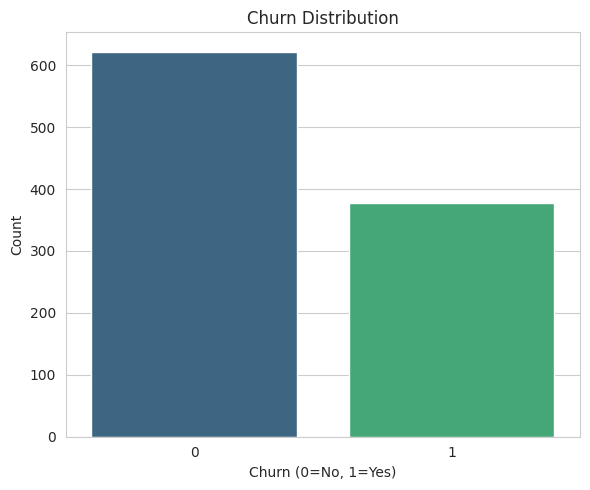

In [ ]:
# Exploratory Data Analysis (EDA) - Churn Distribution

sns.set_style('whitegrid')
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Churn Distribution')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Senior Citizen vs Churn

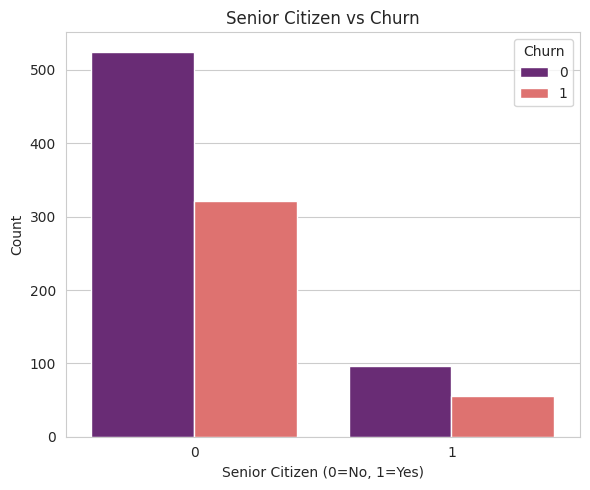

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='magma')
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Contract Type vs Churn

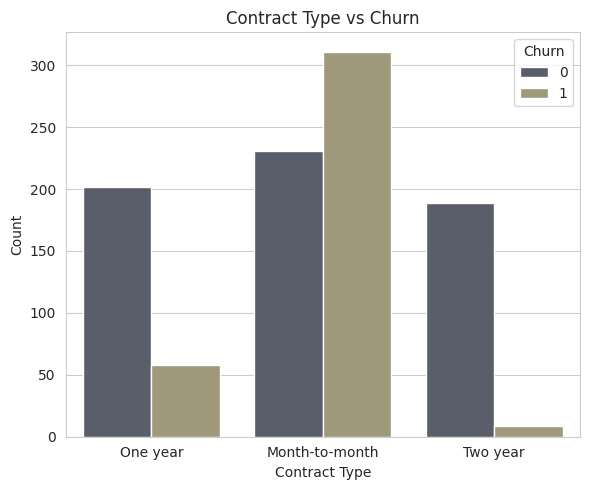

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='cividis')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


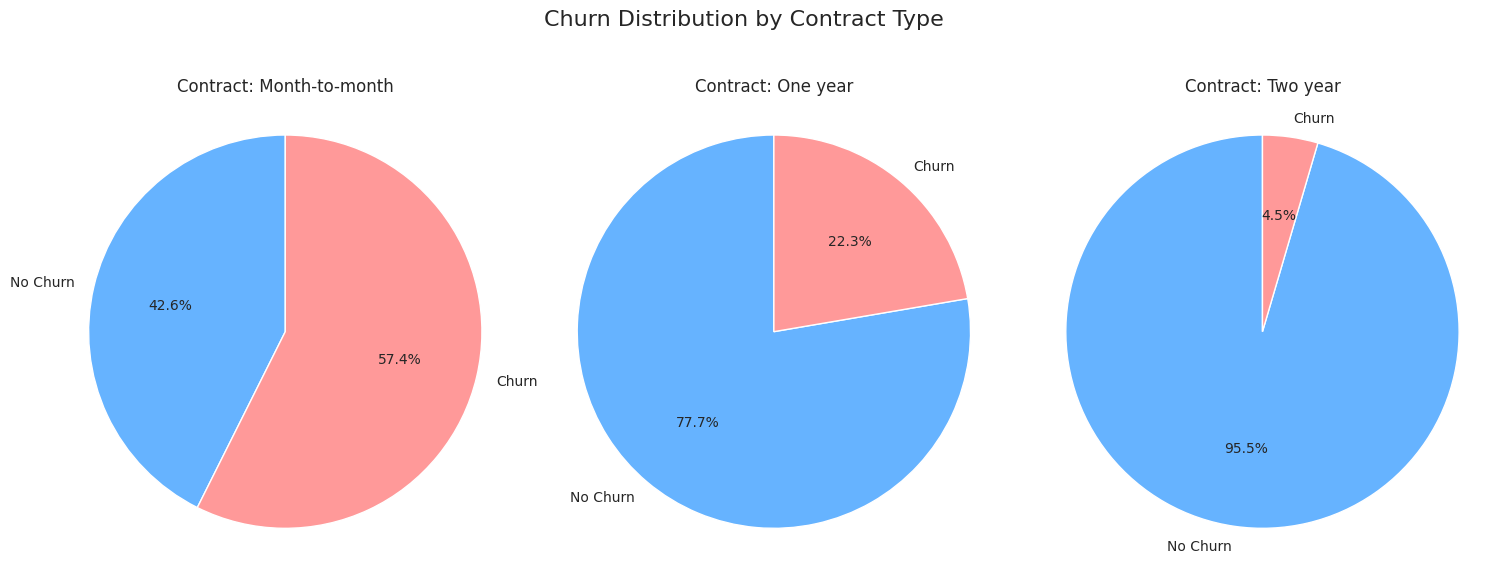

In [ ]:
# Pie Chart for Contract Type vs Churn
contract_churn_distribution = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().fillna(0)

fig, axes = plt.subplots(1, len(contract_churn_distribution.index), figsize=(15, 6))
fig.suptitle('Churn Distribution by Contract Type', fontsize=16)

for i, contract_type in enumerate(contract_churn_distribution.index):
    ax = axes[i]
    churn_values = contract_churn_distribution.loc[contract_type]
    ax.pie(churn_values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
    ax.set_title(f'Contract: {contract_type}')
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Internet Service vs Churn

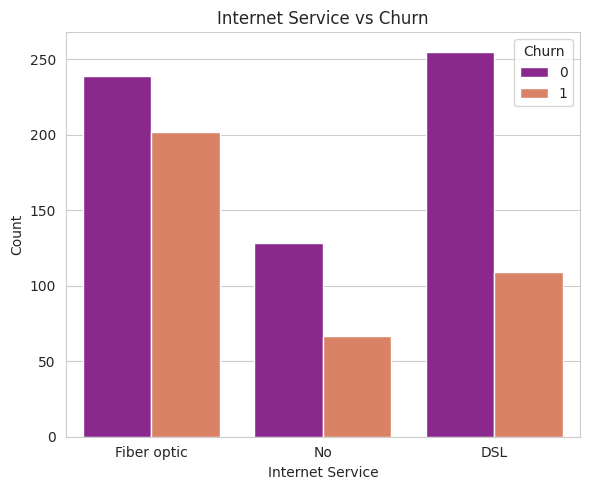

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='plasma')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Monthly Charges Distribution

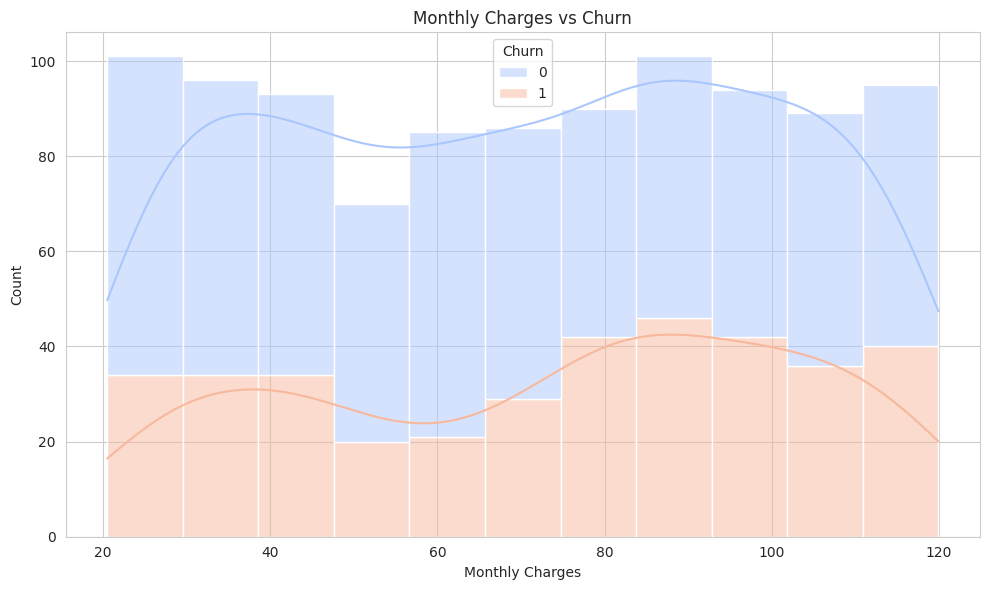

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', kde=True, palette='coolwarm')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Tenure Distribution

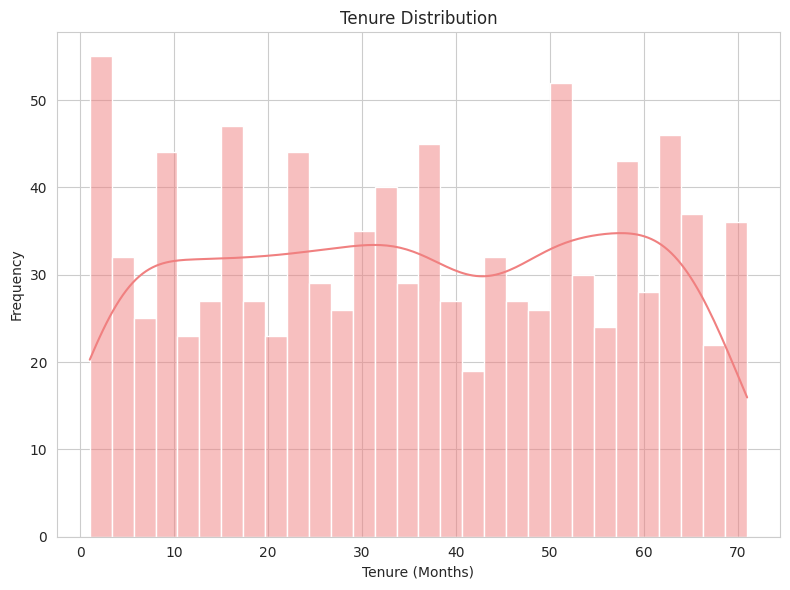

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['tenure'], bins=30, kde=True, color='lightcoral')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation Heatmap of Numerical Features

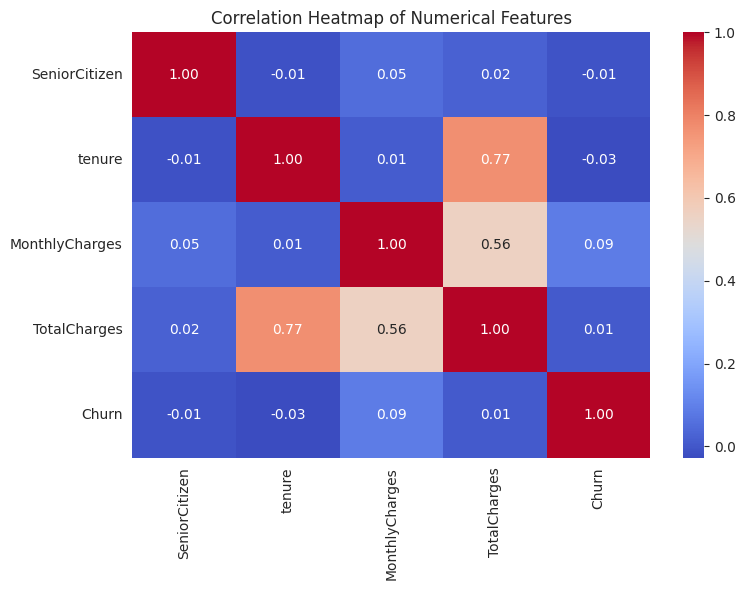

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

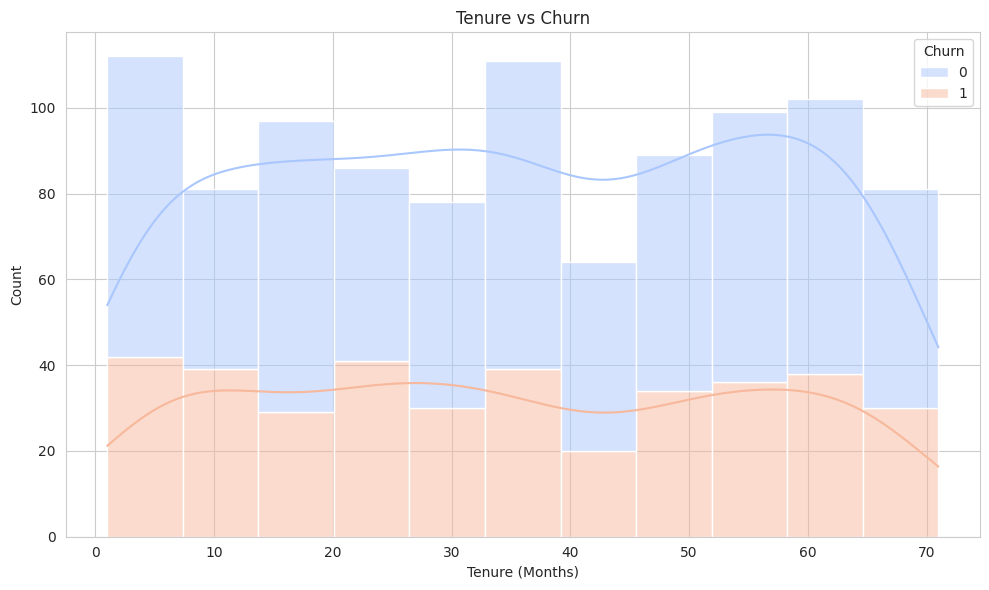

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True, palette='coolwarm')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# Data Preparation for Model Training

# Define features (X) and target (y)
# The 'Churn' column is our target variable.
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Identify numerical columns for scaling
# Assuming numerical columns are all non-boolean and not 'Churn' in df_processed
# (excluding the dummy variables which are already binary/numeric)
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'] # Explicitly define numerical columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Display the first few rows of the processed and scaled features
display(X.head())

# Display the target variable distribution
print(f"Target variable (y) distribution:\n{y.value_counts()}")

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TechSupport_Yes,OnlineSecurity_Yes
0,-0.425015,0.797666,1.196517,1.507662,True,False,True,False,False,False,True,True,True
1,2.352859,-0.989848,1.109478,-0.464157,True,False,True,False,False,True,False,False,True
2,-0.425015,1.232467,-0.368475,0.499254,True,False,True,False,False,True,False,True,False
3,-0.425015,-0.699981,0.556184,-0.350065,False,False,True,False,True,False,False,True,False
4,-0.425015,-0.555048,-1.024509,-0.783158,False,True,False,True,False,False,False,False,True


Target variable (y) distribution:
Churn
0    622
1    378
Name: count, dtype: int64


In [ ]:
# Split the data into training and testing sets
# We use a test size of 20% and a random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\ny_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\ny_test distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (800, 13)
X_test shape: (200, 13)
y_train shape: (800,)
y_test shape: (200,)

y_train distribution:
Churn
0    0.6225
1    0.3775
Name: proportion, dtype: float64

y_test distribution:
Churn
0    0.62
1    0.38
Name: proportion, dtype: float64


In [ ]:
# Model Building and Training

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)
print("Logistic Regression Model Trained.")

# Initialize and train Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier Model Trained.")

Logistic Regression Model Trained.
Random Forest Classifier Model Trained.


## Model Evaluation

### Logistic Regression Model Evaluation

#### Logistic Regression Model Performance ####
Accuracy: 0.6900

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.75       124
           1       0.59      0.62      0.60        76

    accuracy                           0.69       200
   macro avg       0.67      0.68      0.67       200
weighted avg       0.69      0.69      0.69       200


Confusion Matrix:


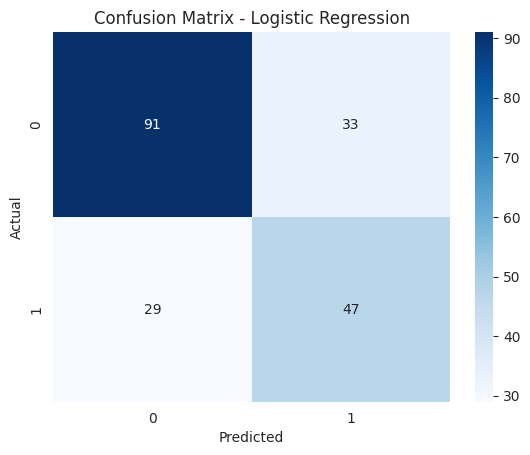

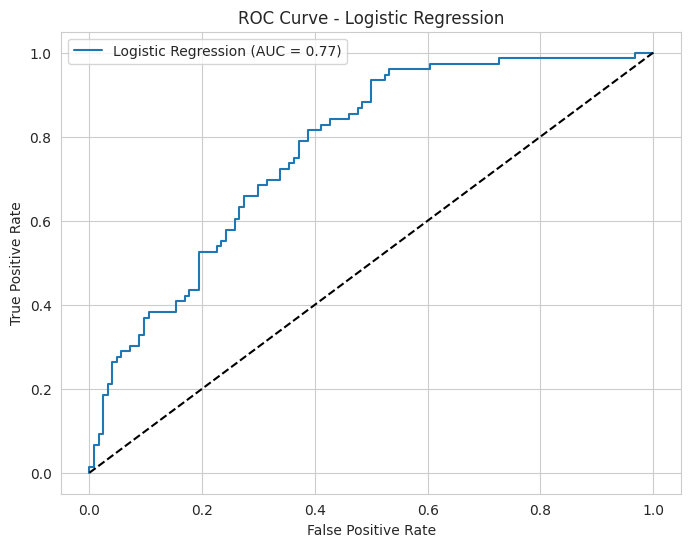

ROC AUC Score: 0.7689


In [ ]:
# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("#### Logistic Regression Model Performance ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()
print(f"ROC AUC Score: {auc_lr:.4f}")

### Random Forest Classifier Model Evaluation

#### Random Forest Classifier Model Performance ####
Accuracy: 0.6450

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       124
           1       0.54      0.47      0.50        76

    accuracy                           0.65       200
   macro avg       0.62      0.61      0.61       200
weighted avg       0.64      0.65      0.64       200


Confusion Matrix:


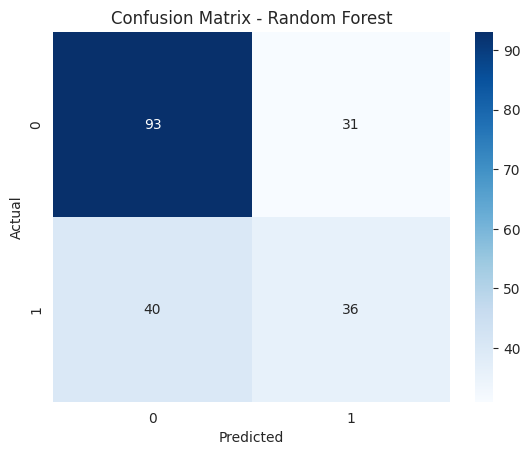

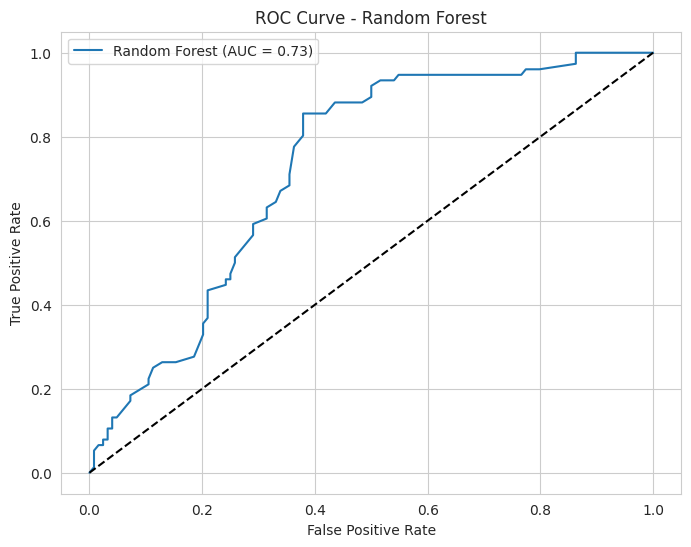

ROC AUC Score: 0.7289


In [ ]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("#### Random Forest Classifier Model Performance ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()
print(f"ROC AUC Score: {auc_rf:.4f}")

## Hyperparameter Tuning

### Logistic Regression Hyperparameter Tuning

Fitting 5 folds for each of 12 candidates, totalling 60 fits
#### Logistic Regression - Best Hyperparameters ####
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best ROC AUC Score: 0.8010

#### Best Logistic Regression Model Performance (Tuned) ####
Accuracy: 0.6900

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       124
           1       0.59      0.63      0.61        76

    accuracy                           0.69       200
   macro avg       0.67      0.68      0.68       200
weighted avg       0.70      0.69      0.69       200



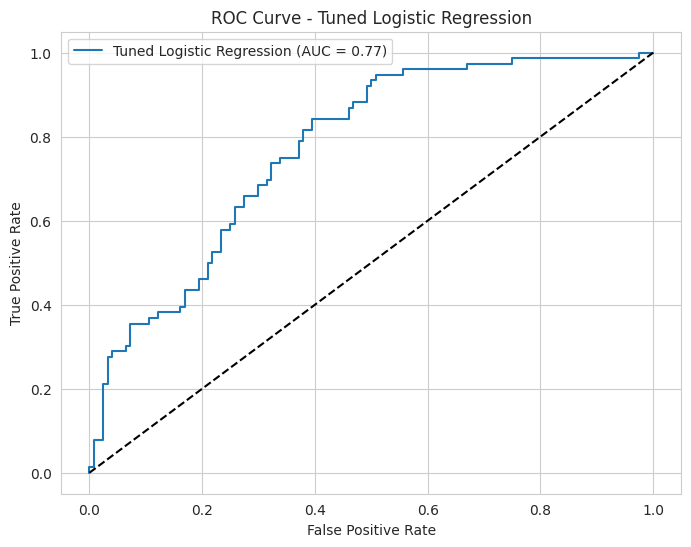

ROC AUC Score (Tuned): 0.7711


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' works with both 'l1' and 'l2' penalties
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit GridSearchCV
grid_search_lr.fit(X_train, y_train)

# Print best parameters and best score
print("#### Logistic Regression - Best Hyperparameters ####")
print(f"Best Parameters: {grid_search_lr.best_params_}")
print(f"Best ROC AUC Score: {grid_search_lr.best_score_:.4f}")

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Evaluate the best Logistic Regression model on the test set
y_pred_best_lr = best_lr_model.predict(X_test)
y_prob_best_lr = best_lr_model.predict_proba(X_test)[:, 1]

print("\n#### Best Logistic Regression Model Performance (Tuned) ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lr))

# ROC Curve and AUC for tuned LR
auc_best_lr = roc_auc_score(y_test, y_prob_best_lr)
fpr_best_lr, tpr_best_lr, _ = roc_curve(y_test, y_prob_best_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best_lr, tpr_best_lr, label=f'Tuned Logistic Regression (AUC = {auc_best_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Logistic Regression')
plt.legend()
plt.show()
print(f"ROC AUC Score (Tuned): {auc_best_lr:.4f}")

### Random Forest Classifier Hyperparameter Tuning

Fitting 5 folds for each of 50 candidates, totalling 250 fits
#### Random Forest - Best Hyperparameters ####
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
Best ROC AUC Score: 0.7839

#### Best Random Forest Model Performance (Tuned) ####
Accuracy: 0.6550

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       124
           1       0.55      0.53      0.54        76

    accuracy                           0.66       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.65      0.66      0.65       200



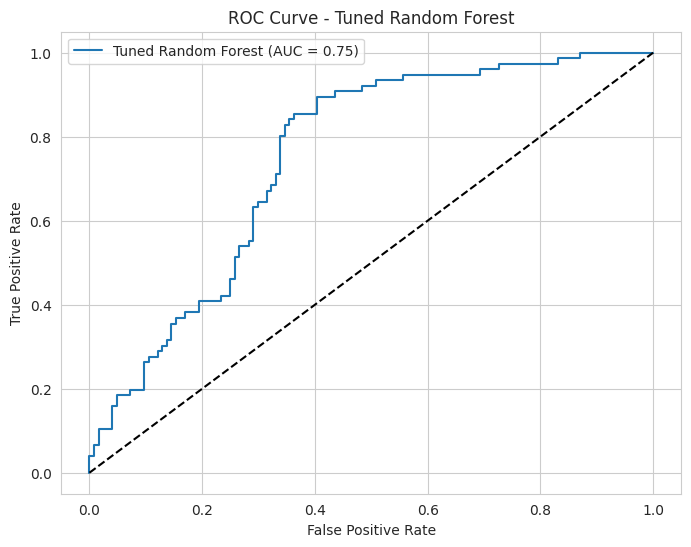

ROC AUC Score (Tuned): 0.7487


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid for Random Forest (using RandomizedSearchCV for efficiency)
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=param_grid_rf, n_iter=50, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1, random_state=42)

# Fit RandomizedSearchCV
random_search_rf.fit(X_train, y_train)

# Print best parameters and best score
print("#### Random Forest - Best Hyperparameters ####")
print(f"Best Parameters: {random_search_rf.best_params_}")
print(f"Best ROC AUC Score: {random_search_rf.best_score_:.4f}")

# Get the best model
best_rf_model = random_search_rf.best_estimator_

# Evaluate the best Random Forest model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("\n#### Best Random Forest Model Performance (Tuned) ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

# ROC Curve and AUC for tuned RF
auc_best_rf = roc_auc_score(y_test, y_prob_best_rf)
fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test, y_prob_best_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best_rf, tpr_best_rf, label=f'Tuned Random Forest (AUC = {auc_best_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend()
plt.show()
print(f"ROC AUC Score (Tuned): {auc_best_rf:.4f}")

## Feature Importance for Best Model (Tuned Logistic Regression)

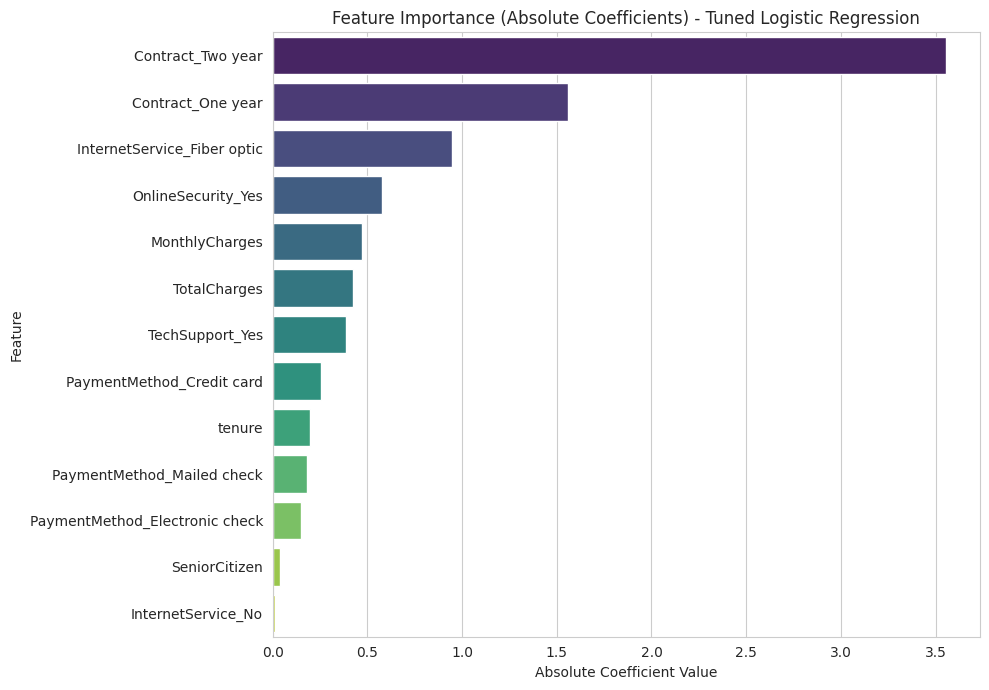

Top 10 Feature Importances (Absolute Coefficients):


,0
Contract_Two year,3.557140
Contract_One year,1.558218
InternetService_Fiber optic,0.948226
OnlineSecurity_Yes,0.575525
MonthlyCharges,0.469202
TotalCharges,0.423053
TechSupport_Yes,0.386626
PaymentMethod_Credit card,0.255842
tenure,0.195778
PaymentMethod_Mailed check,0.179608


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Logistic Regression model
# For Logistic Regression, coefficients indicate feature importance, assuming scaled features
feature_importances_lr = pd.Series(best_lr_model.coef_[0], index=X.columns)

# Sort feature importances
sorted_feature_importances_lr = feature_importances_lr.abs().sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x=sorted_feature_importances_lr.values, y=sorted_feature_importances_lr.index, palette='viridis')
plt.title('Feature Importance (Absolute Coefficients) - Tuned Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 Feature Importances (Absolute Coefficients):")
display(sorted_feature_importances_lr.head(10))

## Feature Importance for Best Random Forest Model

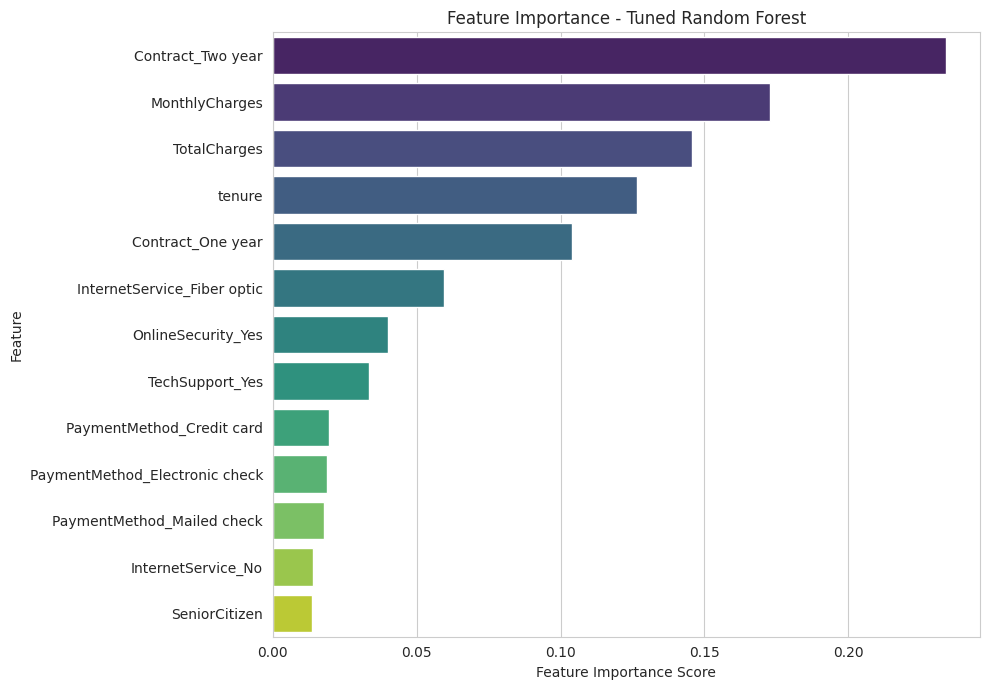

Top 10 Feature Importances (Random Forest):


,0
Contract_Two year,0.234021
MonthlyCharges,0.172877
TotalCharges,0.145707
tenure,0.126679
Contract_One year,0.103959
InternetService_Fiber optic,0.059444
OnlineSecurity_Yes,0.039934
TechSupport_Yes,0.033415
PaymentMethod_Credit card,0.019702
PaymentMethod_Electronic check,0.018698


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best Random Forest model
feature_importances_rf = pd.Series(best_rf_model.feature_importances_, index=X.columns)

# Sort feature importances
sorted_feature_importances_rf = feature_importances_rf.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x=sorted_feature_importances_rf.values, y=sorted_feature_importances_rf.index, palette='viridis')
plt.title('Feature Importance - Tuned Random Forest')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 Feature Importances (Random Forest):")
display(sorted_feature_importances_rf.head(10))

## Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Get metrics for Tuned Logistic Regression
acc_lr_tuned = accuracy_score(y_test, y_pred_best_lr)
auc_lr_tuned = roc_auc_score(y_test, y_prob_best_lr)

# Get metrics for Tuned Random Forest
acc_rf_tuned = accuracy_score(y_test, y_pred_best_rf)
auc_rf_tuned = roc_auc_score(y_test, y_prob_best_rf)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Tuned Logistic Regression', 'Tuned Random Forest'],
    'Accuracy': [acc_lr_tuned, acc_rf_tuned],
    'ROC AUC': [auc_lr_tuned, auc_rf_tuned]
})

display(comparison_df)


,Model,Accuracy,ROC AUC
0,Tuned Logistic Regression,0.690,0.771116
1,Tuned Random Forest,0.655,0.748727


### Confusion Matrix for Tuned Logistic Regression

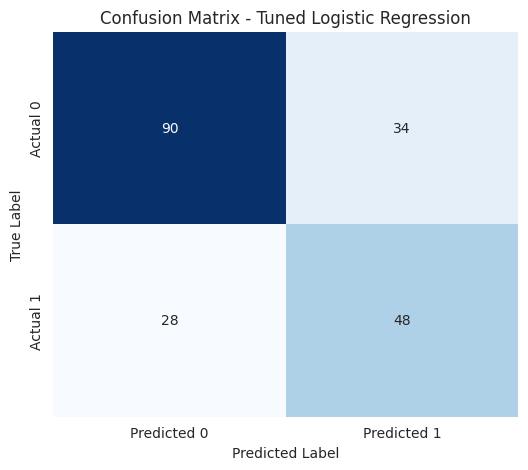

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Tuned Logistic Regression
cm_lr_tuned = confusion_matrix(y_test, y_pred_best_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Reports for Tuned Models

In [ ]:
from sklearn.metrics import classification_report

print("#### Tuned Logistic Regression Classification Report ####")
print(classification_report(y_test, y_pred_best_lr))

print("\n#### Tuned Random Forest Classification Report ####")
print(classification_report(y_test, y_pred_best_rf))

#### Tuned Logistic Regression Classification Report ####
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       124
           1       0.59      0.63      0.61        76

    accuracy                           0.69       200
   macro avg       0.67      0.68      0.68       200
weighted avg       0.70      0.69      0.69       200


#### Tuned Random Forest Classification Report ####
              precision    recall  f1-score   support

           0       0.72      0.73      0.73       124
           1       0.55      0.53      0.54        76

    accuracy                           0.66       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.65      0.66      0.65       200



## Conclusion

In this notebook, we performed an exploratory data analysis (EDA), data preprocessing, model building, hyperparameter tuning, and model comparison for customer churn prediction.

### Key Findings from EDA:
*   Churn distribution shows a class imbalance, with more customers not churning (0) than churning (1).
*   **Senior Citizens** have a higher churn rate compared to non-senior citizens.
*   **Contract Type** plays a significant role, with month-to-month contracts having a much higher churn rate than one-year or two-year contracts.
*   Customers with **Fiber Optic** internet service have a higher churn rate.
*   **Monthly Charges** and **Tenure** also show clear relationships with churn; higher monthly charges and lower tenure are associated with higher churn.

### Model Performance:
We evaluated two models: Logistic Regression and Random Forest Classifier.

| Model                     | Accuracy | ROC AUC |
|:--------------------------|:---------|:--------|
| Tuned Logistic Regression | 0.690    | 0.771   |
| Tuned Random Forest       | 0.655    | 0.749   |

After hyperparameter tuning, the **Logistic Regression** model performed slightly better in terms of both Accuracy (0.690) and ROC AUC (0.771) compared to the Tuned Random Forest model (Accuracy: 0.655, ROC AUC: 0.749).

### Feature Importance:
*   For **Logistic Regression**, `Contract_Two year`, `Contract_One year`, `InternetService_Fiber optic`, `OnlineSecurity_Yes`, `MonthlyCharges`, and `TotalCharges` were among the most important features.
*   For **Random Forest**, `Contract_Two year`, `MonthlyCharges`, `TotalCharges`, and `tenure` were identified as the most influential features.

Overall, the Logistic Regression model provides a reasonably good balance of interpretability and predictive performance for this dataset. Further improvements could involve more advanced feature engineering, exploring other classification algorithms, or using techniques to address class imbalance more directly.